In [1]:
from pathlib import Path
import random

In [2]:
datadir = Path("./data/ferrari_dataset")

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

example = in this dataset, we have 13 unique model ferrari car and 197 unique images
- *n_way* = number of class for each "episode"
- *m_shot* = usable images for each class in a episode
- *task* = n way m shot for example we are using five way one shot and five q_queries
- *support set* = consist of m shot for each class. 
- *q_queries* = like validation set. shows the generally capacity of the model.

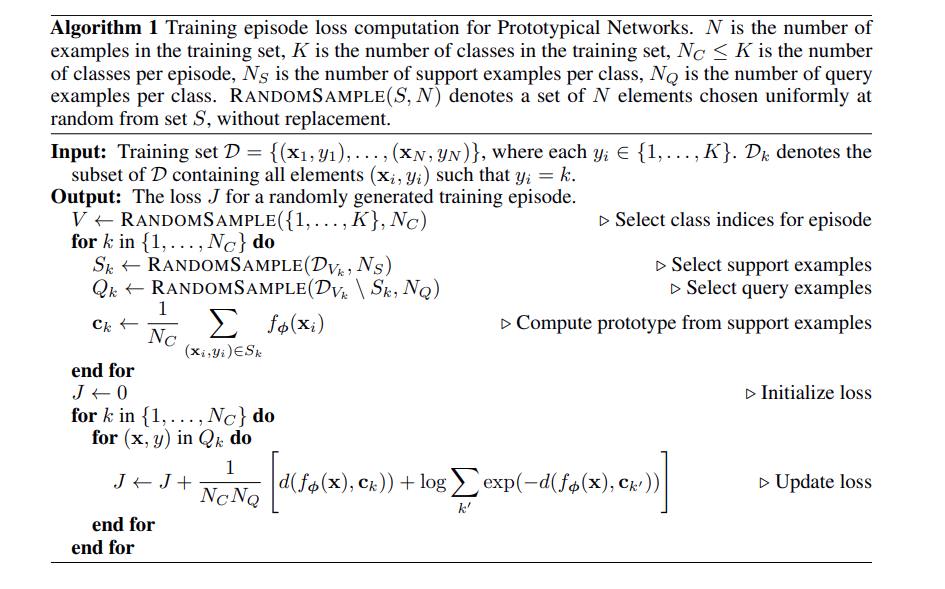

- All sets (query + support) giving to CNN model. Cnn generating representation vectors (embedding vec) [0.2, 0.5, 0.7, ...] etc.
- The average values of the embedding vectors of the same classes are taken. These values are prototype of the that class.
- Query samples are converted into embedding vectors and calculating distance for all other prototypes. Closest prototype is predicted class.
- Calculating loss with log_softmax + nll loss

In [5]:
class FewShotDataset(Dataset):
    def __init__(self, subset, n_way=5, k_shot=1, q_queries=5, transform=None):
        self.dataset = subset # like train-test subset
        self.transform = transform # if using transform
        self.n_way=n_way # number of class
        self.k_shot = k_shot # support set for each class. what the model will see
        self.q_queries = q_queries # samples that the model doesn't see

        self.class2idx = {}

        for idx, (imgs, labels) in enumerate(self.dataset):
            self.class2idx.setdefault(labels, []).append(idx)
            """
            0: [1, 3, 9]
            1: [2, 5, 7]
            ...
            """
        self.available_classes = [cls for cls, idxs in self.class2idx.items() if len(idxs) >= (k_shot + q_queries)]
        # not take if any class have not enough images
    def __len__(self):
        return 1000000
        
    def __getitem__(self, idx):
        selected_classes = random.sample(self.available_classes, self.n_way)
        support_imgs, support_labels = [], []
        query_imgs, query_labels = [], []

        label_map = {cls: i for i, cls in enumerate(selected_classes)}
        """ sorting 0 to n_way
        4: 0
        7: 1
        5: 2
        ...
        """
        for cls in selected_classes:
            indices = random.sample(
                self.class2idx[cls],
                self.k_shot + self.q_queries
            ) # we are taking q+k sample
            support_idxs = indices[:self.k_shot]
            query_idxs = indices[self.k_shot:]

            for idx in support_idxs:
                img, _ = self.dataset[idx]
                if self.transform:
                    img = self.transform(img)
                support_imgs.append(img)
                support_labels.append(label_map[cls])
                
            for idx in query_idxs:
                img, _ = self.dataset[idx]
                if self.transform:
                    img = self.transform(img)
                query_imgs.append(img)
                query_labels.append(label_map[cls])

        return (
            torch.stack(support_imgs), torch.tensor(support_labels),
            torch.stack(query_imgs), torch.tensor(query_labels)
            )

In [6]:
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder

In [7]:
train_transform = transforms.Compose([transforms.RandomResizedCrop(320, scale=(0.6, 1.0)),
                                     transforms.RandomHorizontalFlip(),
                                     transforms.ColorJitter(brightness=0.2, 
                                                            contrast=0.2, 
                                                            saturation=0.2),
                                     transforms.RandomAffine(degrees=20, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=20),
                                     transforms.ToTensor(),
                                     transforms.Normalize(mean = [0.5]*3, std=[0.5]*3)
                                     ])
val_transform = transforms.Compose([transforms.Resize(320),
                                    transforms.CenterCrop(320),
                                    transforms.ToTensor(),
                                    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
                                    ])

In [8]:
dataset = ImageFolder(datadir)

train_size = int(len(dataset) * 0.7)
test_size = len(dataset) - train_size

train_subset, test_subset = random_split(dataset, [train_size, test_size])

fewshot_train_dataset = FewShotDataset(train_subset, n_way=5, k_shot=1, q_queries=4, transform=train_transform)
train_episode_loader = DataLoader(fewshot_train_dataset, batch_size=1, shuffle=True, num_workers=16)

fewshot_test_dataset = FewShotDataset(test_subset, n_way=5, k_shot=1, q_queries=4, transform=train_transform)
test_episode_loader = DataLoader(fewshot_test_dataset, batch_size=1, shuffle=True, num_workers=16)

In [9]:
from collections import Counter
test_label_counts = Counter([label for _, label in train_subset])
print("test:", test_label_counts)
train_label_counts = Counter([label for _, label in test_subset])
print("train:", train_label_counts)

test: Counter({1: 24, 9: 19, 10: 16, 12: 16, 8: 10, 0: 10, 11: 8, 6: 7, 7: 6, 5: 6, 3: 6, 2: 5, 4: 4})
train: Counter({1: 11, 11: 8, 9: 8, 0: 6, 12: 5, 10: 4, 3: 4, 6: 4, 7: 3, 2: 2, 4: 2, 5: 2, 8: 1})


In [10]:
class CNN(nn.Module):
    def __init__(self, out_size=13, emb_size=128):
        super().__init__()
        self.conv = nn.Sequential(# [B, 320, 320, 3]
            nn.Conv2d(3, 32, kernel_size=3, padding=1), 
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(2,2), # [B, 160, 160, 32]
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1), 
            nn.BatchNorm2d(64),
            nn.ELU(),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(2,2), # [B, 80, 80, 64]
            
            nn.Conv2d(64, 64, kernel_size=3, padding=1), 
            nn.BatchNorm2d(64),
            nn.ELU(),
            nn.MaxPool2d(2,2), # [B, 40, 40, 64]
            )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(40*40*64, emb_size),
            nn.Dropout(0.4),
            )
        ;
    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)

In [11]:
import torch.nn.functional as F

In [12]:
def prototypical_loss(model, support_imgs, support_labels, query_imgs, query_labels):
    support_emb = F.normalize(model(support_imgs), p=2, dim=1)  # [N*K, 128]
    query_emb = F.normalize(model(query_imgs), p=2, dim=1)      # [N*Q, 128]

    n_classes = support_labels.unique().size(0)
    prototypes = []
    for c in range(n_classes):
        class_emb = support_emb[support_labels == c]
        proto = class_emb.mean(dim=0)
        prototypes.append(proto)
    prototypes = torch.stack(prototypes)  # [N, 128]

    # cosine distance: 1 - cosine_similarity
    dists = 1 - F.cosine_similarity(
        query_emb.unsqueeze(1).expand(-1, n_classes, -1),
        prototypes.unsqueeze(0).expand(query_emb.size(0), -1, -1),
        dim=2
    )

    log_p_y = F.log_softmax(-dists, dim=1)
    loss = F.nll_loss(log_p_y, query_labels)

    pred = log_p_y.argmax(dim=1)
    acc = (pred == query_labels).float().mean().item()
    return loss, acc

In [13]:
model = CNN().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-2, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.5)
best_acc = 0.0

In [15]:
max_episodes = 3000
for episode_idx, episode in enumerate(train_episode_loader):
    if episode_idx >= max_episodes:
        break
    support_images, support_labels, query_images, query_labels = [x.squeeze(0).to(device) for x in episode]

    loss, acc = prototypical_loss(model, support_images, support_labels, query_images, query_labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()
    if episode_idx % 50 == 0:
        print(f"[Episode {episode_idx}] Loss: {loss.item():.4f}, Acc: {acc:.4f}")    
    if acc > best_acc:
        best_acc = acc
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'accuracy': best_acc,
            'loss': loss.item(),
            'episode': episode_idx
        }, "best_model.pth")
        print(f"Saved new best model at episode {episode_idx} | Acc: {acc:.4f} | Loss: {loss.item():.4f} | LR: {optimizer.param_groups[-1]['lr']}")
    torch.cuda.empty_cache()

[Episode 0] Loss: 1.4670, Acc: 0.1500
Saved new best model at episode 4 | Acc: 0.6500 | Loss: 1.3003 | LR: 0.01
[Episode 50] Loss: 1.6739, Acc: 0.1500
[Episode 100] Loss: 1.5034, Acc: 0.4000
Saved new best model at episode 128 | Acc: 0.7500 | Loss: 1.2319 | LR: 0.01
Saved new best model at episode 142 | Acc: 0.9000 | Loss: 1.1621 | LR: 0.01
[Episode 150] Loss: 1.3873, Acc: 0.3500
[Episode 200] Loss: 1.2378, Acc: 0.4500
[Episode 250] Loss: 1.4798, Acc: 0.5000
[Episode 300] Loss: 1.2868, Acc: 0.5500
[Episode 350] Loss: 1.4306, Acc: 0.3500
[Episode 400] Loss: 1.4304, Acc: 0.6000
[Episode 450] Loss: 1.4726, Acc: 0.5000
[Episode 500] Loss: 1.3868, Acc: 0.4000
[Episode 550] Loss: 1.5174, Acc: 0.5000
Saved new best model at episode 589 | Acc: 0.9500 | Loss: 1.1520 | LR: 0.005
[Episode 600] Loss: 1.4527, Acc: 0.4000
[Episode 650] Loss: 1.2655, Acc: 0.3500
[Episode 700] Loss: 1.3587, Acc: 0.5500
Saved new best model at episode 720 | Acc: 1.0000 | Loss: 1.1842 | LR: 0.005
[Episode 750] Loss: 1.2

KeyboardInterrupt: 

In [ ]:
checkpoint = torch.load("best_model.pth")
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded model from episode {checkpoint['episode']}, Acc: {checkpoint['accuracy']:.4f}")

In [16]:
def evaluate(model, episode_loader, device):
    model.eval()
    acc_list = []

    with torch.no_grad():
        for episode in episode_loader:
            support_images, support_labels, query_images, query_labels = [
                x.squeeze(0).to(device) for x in episode
            ]
            loss, acc = prototypical_loss(model, support_images, support_labels, query_images, query_labels)
            acc_list.append(acc)

    avg_acc = sum(acc_list) / len(acc_list)
    print(f"Evaluation Accuracy over {len(acc_list)} episodes: {avg_acc:.4f}")
    return avg_acc

In [ ]:
evaluate(model, test_episode_loader, device)